<a href="https://colab.research.google.com/github/faisu6339-glitch/ML-Projects-/blob/main/P_14_Bank_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('bank.csv')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
df.shape

(11162, 17)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
print(num_cols)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


In [ ]:
cat_cols=df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')


In [ ]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    print(col, "outliers count:", len(outliers))
    print(outliers.head())
    print("-"*50)

age outliers count: 171
1162    75
1236    85
1243    90
1274    85
1320    83
Name: age, dtype: int64
--------------------------------------------------
balance outliers count: 1055
9      5090
60     7180
61     5291
69     4580
71    10576
Name: balance, dtype: int64
--------------------------------------------------
day outliers count: 0
Series([], Name: day, dtype: int64)
--------------------------------------------------
duration outliers count: 636
0    1042
1    1467
2    1389
6    1201
9    1297
Name: duration, dtype: int64
--------------------------------------------------
campaign outliers count: 601
125     8
135    11
163     9
186    10
187    15
Name: campaign, dtype: int64
--------------------------------------------------
pdays outliers count: 2750
890    166
891     91
899    147
933    170
951    150
Name: pdays, dtype: int64
--------------------------------------------------
previous outliers count: 1258
891      4
933      3
952      4
968      3
1007    10
Name: p

In [ ]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col} outliers rows:")
    display(outliers)

age outliers rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
1162,75,retired,divorced,primary,no,3881,yes,no,cellular,4,feb,136,3,-1,0,unknown,yes
1236,85,retired,married,primary,no,12114,no,no,telephone,12,feb,165,2,-1,0,unknown,yes
1243,90,retired,divorced,secondary,no,1,no,no,cellular,13,feb,152,3,-1,0,unknown,yes
1274,85,retired,divorced,primary,no,7613,no,no,cellular,18,feb,355,3,-1,0,unknown,yes
1320,83,retired,divorced,primary,no,1097,no,no,telephone,5,mar,181,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10438,77,retired,married,primary,no,1492,no,no,telephone,1,sep,663,1,208,2,other,no
10562,88,retired,married,primary,no,648,no,no,telephone,3,sep,318,1,-1,0,unknown,no
10570,77,unknown,married,unknown,no,397,no,no,telephone,8,nov,207,1,185,3,success,no
10618,78,retired,married,primary,no,680,no,no,telephone,24,may,838,1,89,9,failure,no


balance outliers rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes
60,51,blue-collar,married,secondary,no,7180,yes,no,unknown,14,may,927,1,-1,0,unknown,yes
61,41,blue-collar,divorced,secondary,no,5291,yes,no,unknown,14,may,1423,3,-1,0,unknown,yes
69,44,technician,married,tertiary,no,4580,yes,no,unknown,15,may,911,2,-1,0,unknown,yes
71,29,management,married,tertiary,no,10576,no,no,unknown,15,may,1224,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11073,34,blue-collar,married,primary,no,6718,no,no,cellular,13,jan,278,4,97,1,other,no
11077,54,retired,divorced,tertiary,no,6102,yes,yes,unknown,21,may,86,6,-1,0,unknown,no
11085,60,technician,married,primary,no,4243,yes,no,cellular,4,feb,387,1,251,1,failure,no
11086,42,admin.,married,secondary,no,6445,yes,no,unknown,2,jun,20,8,-1,0,unknown,no


day outliers rows:


...

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
125,35,blue-collar,married,primary,no,994,yes,no,unknown,23,may,1349,8,-1,0,unknown,yes
135,44,technician,divorced,secondary,no,1262,yes,no,unknown,26,may,788,11,-1,0,unknown,yes
163,51,entrepreneur,married,unknown,no,606,yes,no,unknown,28,may,560,9,-1,0,unknown,yes
186,35,technician,divorced,secondary,no,5724,yes,no,unknown,30,may,691,10,-1,0,unknown,yes
187,34,technician,divorced,secondary,no,1451,yes,no,unknown,30,may,1097,15,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11057,31,management,divorced,tertiary,no,-547,yes,yes,cellular,31,jul,101,10,-1,0,unknown,no
11074,37,management,married,tertiary,no,21,no,no,cellular,21,aug,50,12,-1,0,unknown,no
11086,42,admin.,married,secondary,no,6445,yes,no,unknown,2,jun,20,8,-1,0,unknown,no
11139,30,self-employed,single,tertiary,no,2593,no,no,unknown,27,may,662,7,-1,0,unknown,no


pdays outliers rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
890,42,admin.,single,secondary,no,-247,yes,yes,telephone,21,oct,519,1,166,1,other,yes
891,33,services,married,secondary,no,3444,yes,no,telephone,21,oct,144,1,91,4,failure,yes
899,56,technician,married,secondary,no,589,yes,no,unknown,23,oct,518,1,147,2,success,yes
933,34,admin.,married,tertiary,no,899,yes,no,unknown,12,nov,114,1,170,3,failure,yes
951,53,retired,married,tertiary,no,2269,no,no,cellular,17,nov,1091,2,150,1,success,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11125,40,blue-collar,divorced,primary,no,54,yes,no,cellular,13,may,10,5,362,3,other,no
11133,37,management,married,tertiary,no,1594,yes,no,cellular,17,apr,110,1,260,5,failure,no
11145,60,retired,divorced,tertiary,no,-134,no,no,cellular,12,may,243,1,271,4,failure,no
11155,35,blue-collar,married,secondary,no,80,yes,yes,cellular,21,nov,38,2,172,2,failure,no


previous outliers rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
891,33,services,married,secondary,no,3444,yes,no,telephone,21,oct,144,1,91,4,failure,yes
933,34,admin.,married,tertiary,no,899,yes,no,unknown,12,nov,114,1,170,3,failure,yes
952,37,technician,married,secondary,no,5115,yes,no,cellular,17,nov,1210,2,171,4,failure,yes
968,46,management,married,tertiary,no,0,no,no,cellular,18,nov,716,2,110,3,other,yes
1007,33,technician,married,tertiary,no,6843,no,no,cellular,20,nov,755,1,100,10,other,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11092,38,services,married,tertiary,no,0,yes,no,cellular,17,apr,239,1,147,4,failure,no
11125,40,blue-collar,divorced,primary,no,54,yes,no,cellular,13,may,10,5,362,3,other,no
11133,37,management,married,tertiary,no,1594,yes,no,cellular,17,apr,110,1,260,5,failure,no
11145,60,retired,divorced,tertiary,no,-134,no,no,cellular,12,may,243,1,271,4,failure,no


In [ ]:
outlier_counts = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[(df[col] < lower) | (df[col] > upper)][col].count()

    outlier_counts[col] = count

print(outlier_counts)

{'age': np.int64(171), 'balance': np.int64(1055), 'day': np.int64(0), 'duration': np.int64(636), 'campaign': np.int64(601), 'pdays': np.int64(2750), 'previous': np.int64(1258)}


#Want to Exclude Some Columns

For example do not treat age and duration:

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:

    if col not in ['age','duration']:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)

#Verification

In [ ]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    print(col, len(outliers))

age 171
balance 0
day 0
duration 636
campaign 0
pdays 0
previous 0


### Bivariate Analysis: 'job' vs. 'education'

Let's analyze the relationship between the 'job' of a client and their 'education' level. A grouped bar chart will show the counts of different education levels for each job category.

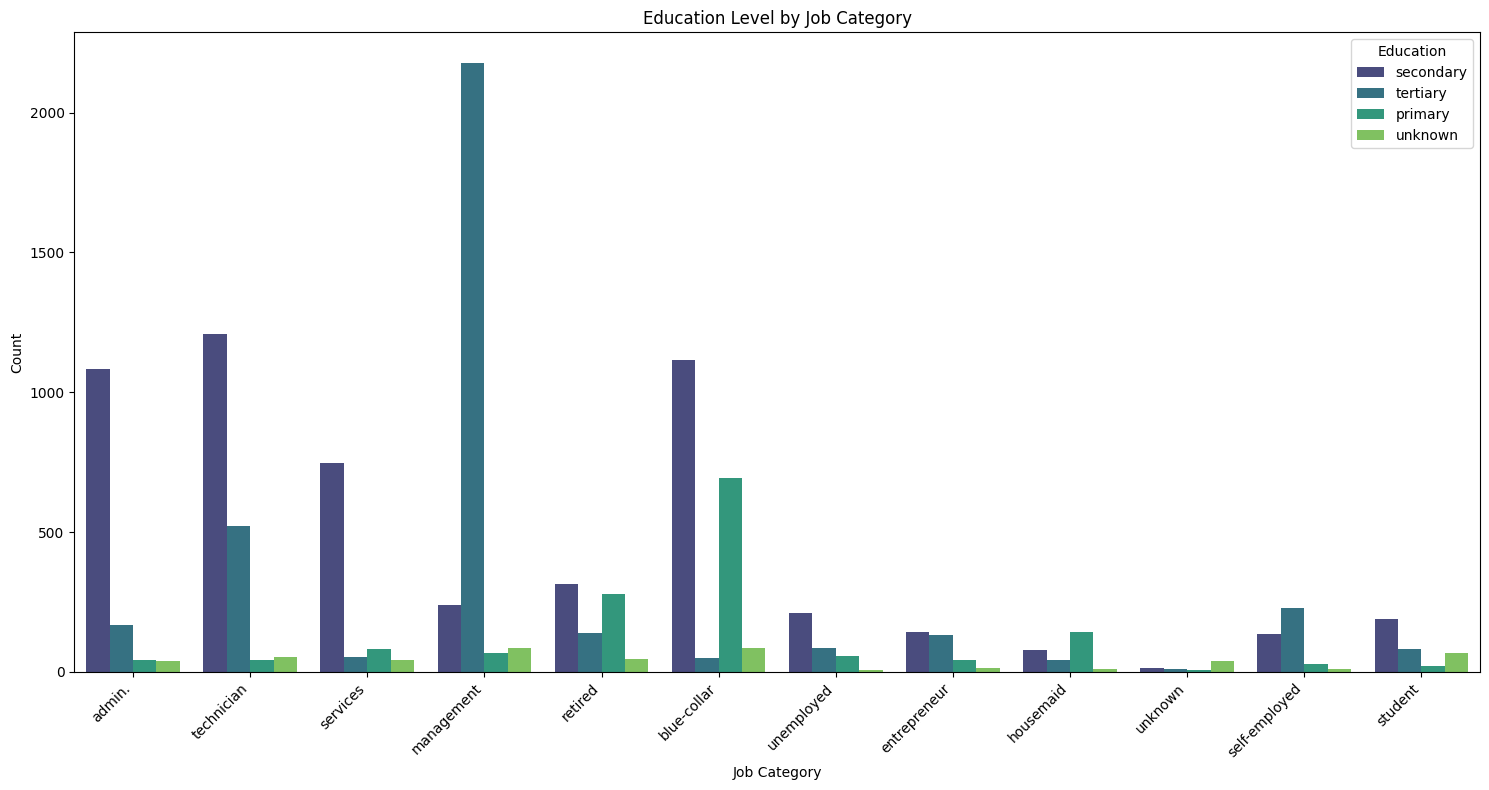

In [ ]:
plt.figure(figsize=(15, 8))
sns.countplot(x='job', hue='education', data=df, palette='viridis')
plt.title('Education Level by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Education')
plt.tight_layout()
plt.show()

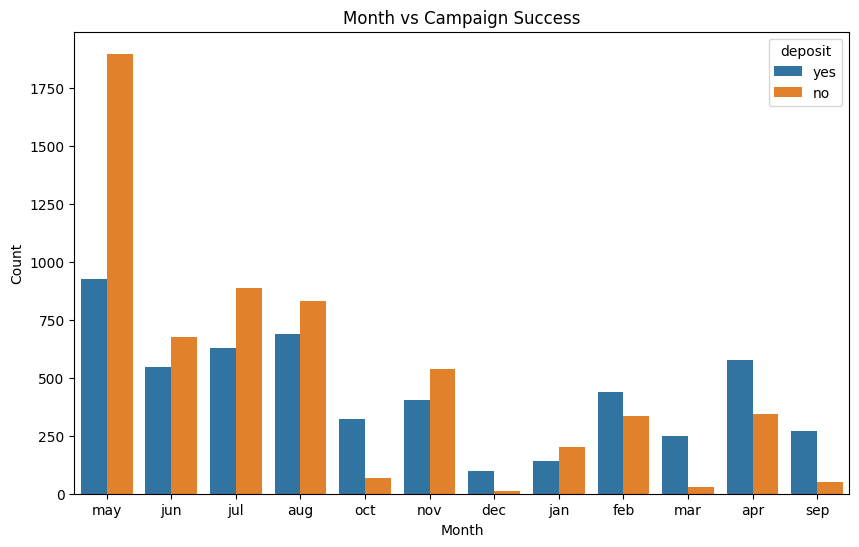

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.countplot(data=df, x='month', hue='deposit')

plt.title("Month vs Campaign Success")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

### Bivariate Analysis: 'marital' vs. 'deposit'

Let's analyze the relationship between the 'marital' status of a client and whether they made a 'deposit'. A grouped bar chart will show the counts of 'yes' and 'no' deposits for each marital status category.

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='marital', hue='deposit', data=df, palette='plasma')
plt.title('Deposit Outcome by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Deposit')
plt.tight_layout()
plt.show()

### Step 1: Encoding Categorical Variables

We need to convert all categorical features into numerical representations that machine learning models can process. We will use one-hot encoding for the input features and label encoding for the target variable 'deposit'.

In [ ]:
# Identify categorical columns again, excluding the target 'deposit'
cat_cols_to_encode = [col for col in df.select_dtypes(include=['object']).columns if col != 'deposit']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols_to_encode, drop_first=True)

# Map the target variable 'deposit' to numerical (0 for 'no', 1 for 'yes')
df_encoded['deposit'] = df_encoded['deposit'].map({'no': 0, 'yes': 1})

print("DataFrame after encoding categorical variables:")
display(df_encoded.head())
print(f"Shape of encoded DataFrame: {df_encoded.shape}")

### Step 2: Data Splitting

Now, we'll split the data into features (X) and the target variable (y), and then divide them into training and testing sets. This ensures that our model is evaluated on data it hasn't seen during training.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('deposit', axis=1)
y = df_encoded['deposit']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

### Step 3: Implement Logistic Regression Model

Let's start by implementing a Logistic Regression model, training it on our prepared `X_train` and `y_train` data, and then evaluating its performance on the `X_test` and `y_test` sets.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and handles L1/L2 regularization

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

### Step 4: Hyperparameter Tuning for Logistic Regression

We will use `GridSearchCV` to find the optimal hyperparameters for the Logistic Regression model. This involves searching over a predefined set of parameters to identify the combination that yields the best performance on our dataset.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for 'lbfgs' and 'saga'

# Initialize GridSearchCV
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best Parameters: ", grid_search.best_params_)
print("Best Cross-validation Accuracy: {:.4f}".format(grid_search.best_score_))

# Get the best model
best_log_reg_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_tuned_log_reg = best_log_reg_model.predict(X_test)

# Evaluate the tuned model
print("\nLogistic Regression Model Performance After Tuning:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned_log_reg):.4f}")

print("\nConfusion Matrix After Tuning:")
print(confusion_matrix(y_test, y_pred_tuned_log_reg))

print("\nClassification Report After Tuning:")
print(classification_report(y_test, y_pred_tuned_log_reg))

### Bivariate Analysis: 'housing' vs. 'deposit'

Let's analyze the relationship between whether a client has a 'housing' loan and whether they made a 'deposit'. A grouped bar chart will show the counts of 'yes' and 'no' deposits for clients with and without housing loans.

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='housing', hue='deposit', data=df, palette='GnBu')
plt.title('Deposit Outcome by Housing Loan Status')
plt.xlabel('Housing Loan')
plt.ylabel('Count')
plt.legend(title='Deposit')
plt.tight_layout()
plt.show()

### Distribution of 'duration' Column

Let's visualize the distribution of the 'duration' column using a histogram. This will help us understand the range of call durations and identify any common patterns or outliers.

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'], bins=30, kde=True, color='purple')
plt.title('Distribution of Duration')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

### Bivariate Analysis: 'education' vs. 'deposit'

Let's analyze the relationship between the 'education' level of a client and whether they made a 'deposit'. A grouped bar chart will show the counts of 'yes' and 'no' deposits for each education category.

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='education', hue='deposit', data=df, palette='viridis')
plt.title('Deposit Outcome by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Deposit')
plt.tight_layout()
plt.show()

### Bivariate Analysis: 'job' vs. 'deposit'

Let's analyze the relationship between the 'job' of a client and whether they made a 'deposit'. A grouped bar chart will show the counts of 'yes' and 'no' deposits for each job category.

In [ ]:
plt.figure(figsize=(15, 8))
sns.countplot(x='job', hue='deposit', data=df, palette='pastel')
plt.title('Deposit Outcome by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Deposit')
plt.tight_layout()
plt.show()

### Exploring Categorical Columns

Let's start by visualizing the distribution of the 'job' column using a count plot. This will show us the frequency of different job categories in the dataset.

In [ ]:
plt.figure(figsize=(14, 7))
sns.countplot(x='job', data=df, hue='job', palette='viridis', legend=False)
plt.title('Distribution of Job Categories')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Next, let's look at the 'marital' status distribution.

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='marital', data=df, hue='marital', palette='cividis', legend=False)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

Finally, let's visualize the 'education' levels.

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='education', data=df, hue='education', palette='magma', legend=False)
plt.title('Distribution of Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

### Distribution of 'balance' Column

Let's visualize the distribution of the 'balance' column using a histogram. This will help us understand the range of balances and identify any common patterns or outliers.

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['balance'], bins=30, kde=True, color='lightgreen')
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

### Univariate Analysis for Numerical Columns

Let's visualize the distribution of some numerical columns. First, a count plot for the 'day' column to see the frequency of observations per day of the month.

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='day', data=df, hue='day', palette='viridis', legend=False)
plt.title('Distribution of Day of the Month')
plt.xlabel('Day of Month')
plt.ylabel('Count')
plt.show()

Next, a histogram for the 'age' column to see the distribution of ages in the dataset. A histogram is generally more appropriate for continuous numerical data.

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models dictionary
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

# Create results dataframe
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.797582   0.795322  0.771267  0.783109
1        Decision Tree  0.788177   0.781521  0.767486  0.774440
2        Random Forest  0.854008   0.818261  0.889414  0.852355
3    Gradient Boosting  0.848186   0.825929  0.861059  0.843128
4             AdaBoost  0.813704   0.801692  0.806238  0.803959


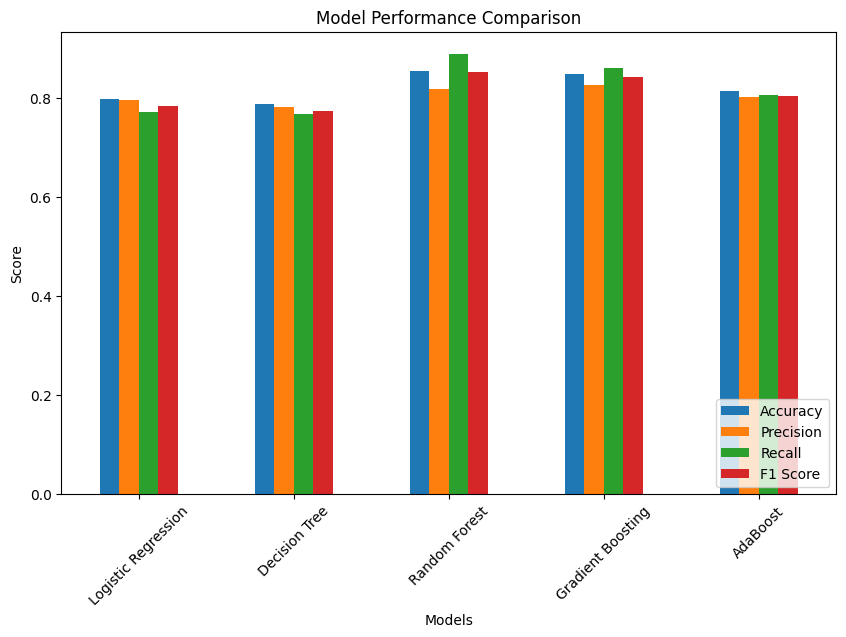

In [ ]:
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

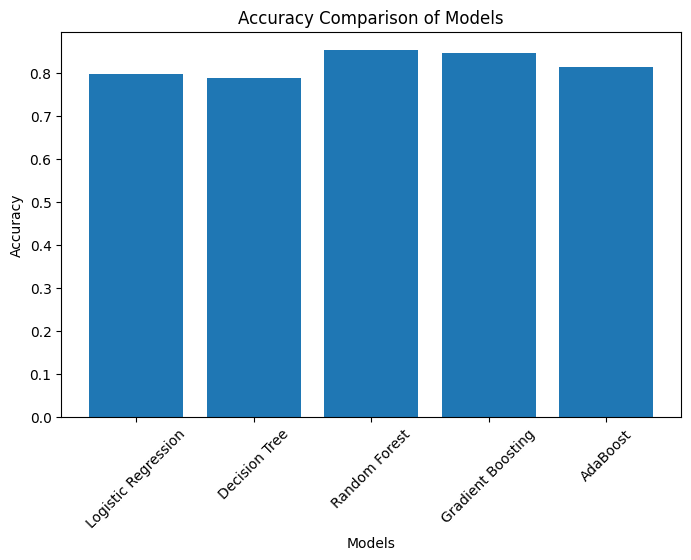

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

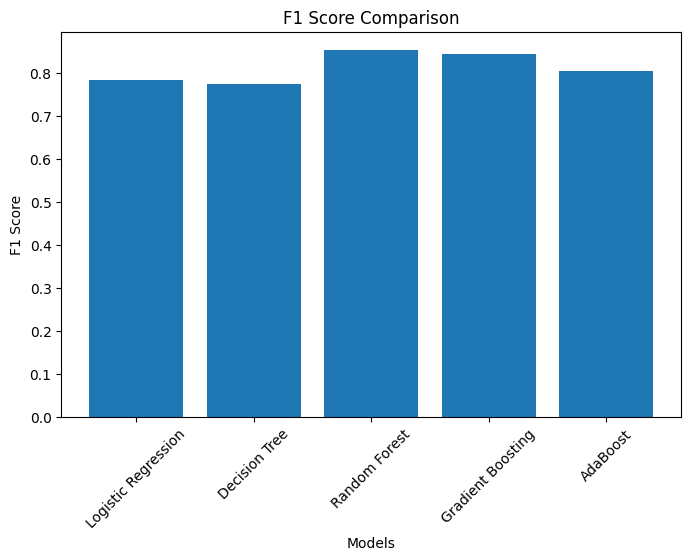

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

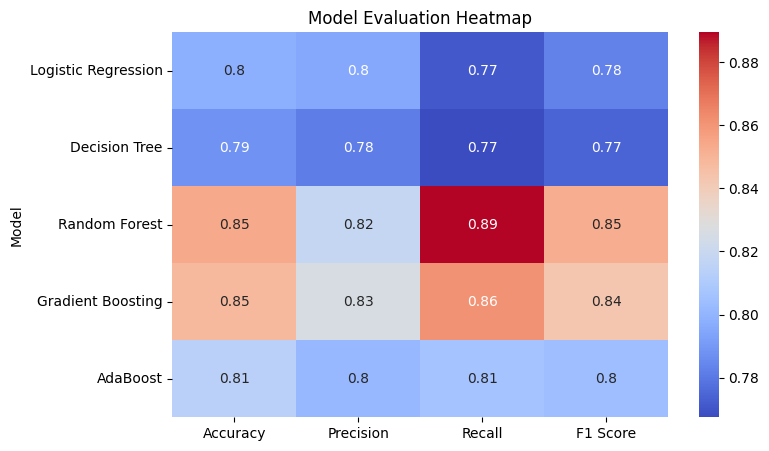

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.heatmap(results_df.set_index("Model"), annot=True, cmap="coolwarm")

plt.title("Model Evaluation Heatmap")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


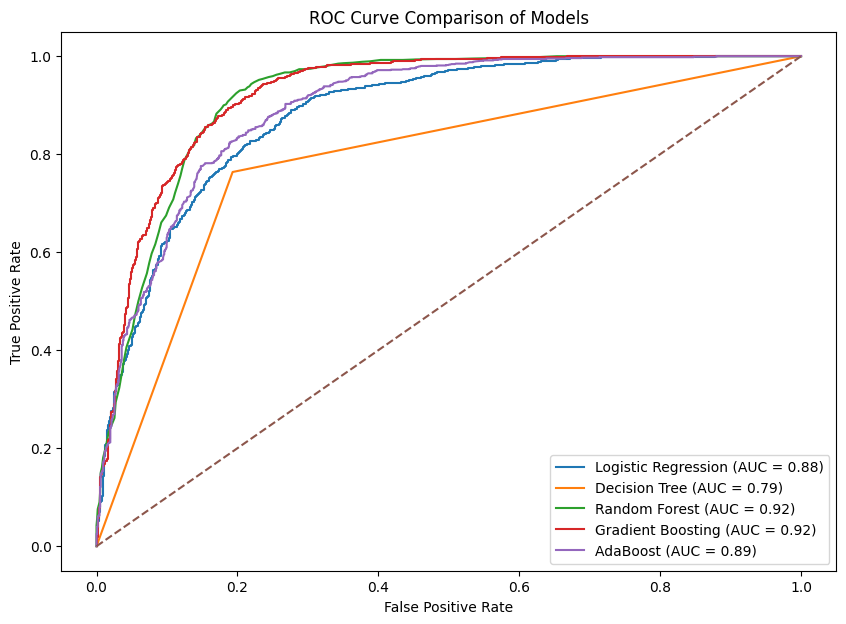

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10,7))

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Get predicted probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

# Random classifier line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 0 0 1 0 0 0 1 1]


In [ ]:
import pandas as pd

# Create a DataFrame for the new customer with all columns from X_train, initialized to False
# X_train is a global variable from the previous steps.
new_customer_data_df = pd.DataFrame(False, index=[0], columns=X_train.columns)

# Numerical values provided in the original new_customer list
numerical_col_names = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
numerical_values = [35, 2000, 15, 300, 2, 999, 0]

# Populate numerical features
for i, col_name in enumerate(numerical_col_names):
    if col_name in new_customer_data_df.columns:
        new_customer_data_df[col_name] = numerical_values[i]

# Populate example categorical features (adjust these based on the actual new customer's attributes)
# For illustration, let's assume:
# job='admin.' (so 'job_admin.' is True, others 'job_X' are False)
# marital='married' (so 'marital_married' is True)
# education='secondary' (so 'education_secondary' is True)
# default='no' (so 'default_yes' is False, which is the default value)
# housing='yes' (so 'housing_yes' is True)
# loan='no' (so 'loan_yes' is False, which is the default value)
# contact='unknown' (so 'contact_unknown' is True)
# month='may' (so 'month_may' is True)
# poutcome='unknown' (so 'poutcome_unknown' is True)

if 'job_admin.' in new_customer_data_df.columns:
    new_customer_data_df['job_admin.'] = True
if 'marital_married' in new_customer_data_df.columns:
    new_customer_data_df['marital_married'] = True
if 'education_secondary' in new_customer_data_df.columns:
    new_customer_data_df['education_secondary'] = True
if 'housing_yes' in new_customer_data_df.columns:
    new_customer_data_df['housing_yes'] = True
if 'contact_unknown' in new_customer_data_df.columns:
    new_customer_data_df['contact_unknown'] = True
if 'month_may' in new_customer_data_df.columns:
    new_customer_data_df['month_may'] = True
if 'poutcome_unknown' in new_customer_data_df.columns:
    new_customer_data_df['poutcome_unknown'] = True

new_customer = new_customer_data_df


In [ ]:
prediction = model.predict(new_customer)

print(prediction)

[0]


In [ ]:
if prediction[0] == 1:
    print("Customer will subscribe")
else:
    print("Customer will NOT subscribe")

Customer will NOT subscribe
